In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import jax, jax.numpy as jnp
from jax import random, vmap
import matplotlib.pyplot as plt
import arviz as az
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from pathlib import Path
from datetime import datetime
import time

from TwoNeuron_JAX import (   
    ModelParams, NoiseParams,
    simulate_pair_jit,   
    pred_sigma,          
)

jax.config.update("jax_enable_x64", True)

# set up data and output paths
DATA_DIR  = "."
OUT_DIR   = "mcmc_inf_out"
Path(OUT_DIR).mkdir(exist_ok=True)

# choose which true weights to test and how many random cases per weight
FIXED_WEIGHTS     = [6.5, 7.0, 8.0, 9.5]
CASES_PER_WEIGHT  = 5
K                  = 1  
MODE               = "file"

# prior range for weight w
W_LOW, W_HIGH = 6.0, 10.0

# MCMC (NUTS) settings
WARMUP, DRAWS = 2000, 2000
CHAINS = 4
TARGET_ACCEPT = 0.9
GRID_N = 201

# simulation and noise setup
cfg   = ModelParams()
noise = NoiseParams(sigma_f=4e-4, gamma=1e-4, sigma_c=28.0, floor=1e-3)

# run the simulator once for a given w and get predicted calcium and fluorescence
@jax.jit
def forward_CF(w):
    return simulate_pair_jit(w, cfg)

# get predicted fluorescence and noise sigma values for K observations
def fwd_sigma_for_K(w, K_obs):
    C2, F2 = forward_CF(w)
    Ck = jnp.broadcast_to(C2, (K_obs, *C2.shape))
    Fk = jnp.broadcast_to(F2, (K_obs, *F2.shape))
    Sig = pred_sigma(Fk, Ck, cfg, noise)
    return Fk, Sig

# evaluate pooled negative log-likelihood over a grid of w values
def pooled_nll_grid(Y_obs, w_grid):
    K_obs = Y_obs.shape[0]
    def nll_at(w):
        Fk, Sig = fwd_sigma_for_K(w, K_obs)
        z = (Fk - Y_obs) / Sig
        nll = 0.5 * (z*z + 2.0*jnp.log(Sig) + jnp.log(2.0*jnp.pi))
        return jnp.sum(nll)
    return vmap(nll_at)(w_grid)

# numpyro model definition
def model(Y_obs):
    K_obs = Y_obs.shape[0]
    w = numpyro.sample("w", dist.Uniform(W_LOW, W_HIGH))
    Fk, Sig = fwd_sigma_for_K(w, K_obs)
    numpyro.sample(
        "y",
        dist.Normal(Fk.reshape(K_obs, -1), Sig.reshape(K_obs, -1)).to_event(1),
        obs=Y_obs.reshape(K_obs, -1)
    )

# build MCMC runner
def make_mcmc():
    kernel = NUTS(model, target_accept_prob=TARGET_ACCEPT)
    return MCMC(
        kernel,
        num_warmup=WARMUP,
        num_samples=DRAWS,
        num_chains=CHAINS,
        chain_method="parallel" if jax.local_device_count() >= CHAINS else "sequential",
        progress_bar=True,
    )

# run the MCMC and return inference results
def run_mcmc(Y_obs, seed=0):
    mcmc = make_mcmc()
    key = random.PRNGKey(seed)
    mcmc.run(key, Y_obs=jnp.asarray(Y_obs, dtype=jnp.float64))
    return az.from_numpyro(mcmc)

# make a traceplot for w
def save_traceplot(idata, path_png, title=""):
    az.plot_trace(idata, var_names=["w"])
    if title:
        plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(path_png, dpi=160)
    plt.close()

# plot the posterior over w
def save_posterior(idata, path_png, true_w=None, title=""):
    w = idata.posterior["w"].values.reshape(-1)
    lo, hi = np.percentile(w, [0.5, 99.5])
    plt.figure(figsize=(7, 5))
    plt.hist(w, bins=80, range=(lo, hi), density=True, alpha=0.35, label="Posterior")
    try:
        from scipy.stats import gaussian_kde
        xx = np.linspace(lo, hi, 1201)
        kde = gaussian_kde(w)
        plt.plot(xx, kde(xx), lw=2, label="KDE")
    except Exception:
        pass
    if true_w is not None:
        plt.axvline(true_w, ls="--", label=f"true w={true_w}")
    plt.xlim(lo, hi)
    plt.title(title)
    plt.xlabel("w (mV)")
    plt.ylabel("density")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path_png, dpi=160)
    plt.close()

# plot pooled NLL curve over w grid
def save_grid(w_grid, nll, path_png, true_w=None):
    arr_w, arr_nll = np.asarray(w_grid), np.asarray(nll)
    plt.figure(figsize=(7, 4))
    plt.plot(arr_w, arr_nll, lw=2)
    if true_w is not None:
        plt.axvline(true_w, ls="--", c="k", label=f"true={true_w}")
    w_hat = float(arr_w[np.argmin(arr_nll)])
    plt.axvline(w_hat, ls=":", c="C1", label=f"MLE≈{w_hat:.3f}")
    plt.xlabel("w (mV)")
    plt.ylabel("pooled NLL")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path_png, dpi=160)
    plt.close()
    return w_hat

# pick K random traces from the file for a given weight
def get_Y_obs_from_file(w_true, K, rng):
    Y = np.load(Path(DATA_DIR) / f"Y_w{w_true}.npy")
    idxs = rng.integers(0, Y.shape[0], size=K)
    return Y[idxs].astype(np.float64), idxs.tolist()

# main loop to run MCMC on each (weight, case)
if __name__ == "__main__":
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")

    total_time = 0.0
    times = []

    for i, w_true in enumerate(FIXED_WEIGHTS):
        for case in range(CASES_PER_WEIGHT):
            # choose a reproducible random index for this weight/case
            rng = np.random.default_rng(10_000 * i + case)

            # grab one observation (K=1) and store its index for CM use
            Y_obs, idxs = get_Y_obs_from_file(w_true, K, rng)

            tag = f"w{w_true}_K{K}_case{case}_{ts}"
            out_dir = Path(OUT_DIR) / tag
            out_dir.mkdir(parents=True, exist_ok=True)

            # save the index locally and in the root for CM to reuse
            np.save(out_dir / f"indices_w{w_true}_K{K}_case{case}.npy",
                    np.array(idxs, dtype=np.int64))
            stable_idx_path = Path(OUT_DIR) / f"indices_w{w_true}_K{K}_case{case}.npy"
            np.save(stable_idx_path, np.array(idxs, dtype=np.int64))
            print(f"Saved indices for w={w_true}, case={case}: {stable_idx_path}")

            # run a quick pooled-NLL scan across a grid to see where the peak is
            w_grid = jnp.linspace(W_LOW, W_HIGH, GRID_N)
            nll = pooled_nll_grid(jnp.asarray(Y_obs), w_grid)
            w_mle = save_grid(w_grid, nll, out_dir / f"{tag}_gridNLL.png", true_w=w_true)
            print(f"[{tag}] pooled-NLL MLE ≈ {w_mle:.3f}")

            # run MCMC inference and record the time
            t0 = time.perf_counter()
            idata = run_mcmc(Y_obs, seed=2025 + 100*i + case)
            dt = time.perf_counter() - t0
            times.append(dt)
            total_time += dt

            az.to_netcdf(idata, out_dir / f"{tag}.nc")
            print(az.summary(idata, var_names=["w"], round_to=6))

            # make trace and posterior plots for this case
            save_traceplot(idata, out_dir / f"{tag}_trace.png", title=f"w={w_true}, K={K}, case={case}")
            save_posterior(
                idata,
                out_dir / f"{tag}_posterior.png",
                true_w=w_true,
                title=f"Posterior of w (true={w_true}, K={K}, case={case})"
            )

            print(f"saved → {out_dir}")
            print(f"MCMC runtime for w={w_true:.1f}, case={case}: {dt:.2f} s")

    # print timing summary
    print("\n===== MCMC Timing Summary =====")
    print("Per-case times (s):", [f"{t:.2f}" for t in times])
    print(f"Total time over {len(FIXED_WEIGHTS) * CASES_PER_WEIGHT} cases: {total_time:.2f} s")
    print(f"Average time per case: {np.mean(times):.2f} s")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Saved indices for w=6.5, case=0: mcmc_inf_out\indices_w6.5_K1_case0.npy
[w6.5_K1_case0_20251003_121027] pooled-NLL MLE ≈ 6.500


sample: 100%|███████████████████████████| 4000/4000 [00:17<00:00, 225.77it/s, 1 steps of size 7.18e-01. acc. prob=0.96]


      mean        sd    hdi_3%   hdi_97%  mcse_mean   mcse_sd    ess_bulk  \
w  6.50317  0.002173  6.499145  6.507295   0.000039  0.000031  3071.05081   

      ess_tail     r_hat  
w  2783.910708  1.001089  
saved → mcmc_inf_out\w6.5_K1_case0_20251003_121027
MCMC runtime for w=6.5, case=0: 89.37 s
Saved indices for w=6.5, case=1: mcmc_inf_out\indices_w6.5_K1_case1.npy
[w6.5_K1_case1_20251003_121027] pooled-NLL MLE ≈ 6.500


sample: 100%|███████████████████████████| 4000/4000 [00:19<00:00, 209.30it/s, 3 steps of size 5.53e-01. acc. prob=0.97]


...

       mean        sd    hdi_3%   hdi_97%  mcse_mean   mcse_sd     ess_bulk  \
w  9.502075  0.004755  9.493053  9.510756   0.000092  0.000073  2690.412592   

      ess_tail    r_hat  
w  2277.038718  1.00207  
saved → mcmc_inf_out\w9.5_K1_case2_20251003_121027
MCMC runtime for w=9.5, case=2: 43.94 s
Saved indices for w=9.5, case=3: mcmc_inf_out\indices_w9.5_K1_case3.npy
[w9.5_K1_case3_20251003_121027] pooled-NLL MLE ≈ 9.500


sample: 100%|███████████████████████████| 4000/4000 [00:09<00:00, 430.71it/s, 7 steps of size 8.49e-01. acc. prob=0.94]


       mean        sd    hdi_3%   hdi_97%  mcse_mean   mcse_sd    ess_bulk  \
w  9.493136  0.004982  9.483994  9.502829   0.000087  0.000068  3305.46451   

      ess_tail     r_hat  
w  3664.622256  1.000165  
saved → mcmc_inf_out\w9.5_K1_case3_20251003_121027
MCMC runtime for w=9.5, case=3: 40.62 s
Saved indices for w=9.5, case=4: mcmc_inf_out\indices_w9.5_K1_case4.npy
[w9.5_K1_case4_20251003_121027] pooled-NLL MLE ≈ 9.500


sample: 100%|███████████████████████████| 4000/4000 [00:08<00:00, 462.10it/s, 5 steps of size 6.38e-01. acc. prob=0.96]


       mean        sd    hdi_3%   hdi_97%  mcse_mean   mcse_sd     ess_bulk  \
w  9.504406  0.004963  9.495107  9.513859   0.000093  0.000069  2850.705433   

      ess_tail    r_hat  
w  2961.127688  1.00114  
saved → mcmc_inf_out\w9.5_K1_case4_20251003_121027
MCMC runtime for w=9.5, case=4: 40.21 s

===== MCMC Timing Summary =====
Per-case times (s): ['89.37', '84.08', '82.97', '79.49', '76.81', '36.30', '36.00', '40.96', '36.75', '37.39', '40.24', '41.99', '42.53', '44.65', '39.21', '41.94', '40.45', '43.94', '40.62', '40.21']
Total time over 20 cases: 1015.89 s
Average time per case: 50.79 s


Loaded: epoch_18752_trainloss_0.00000066_valloss_0.00000023.pth on cpu


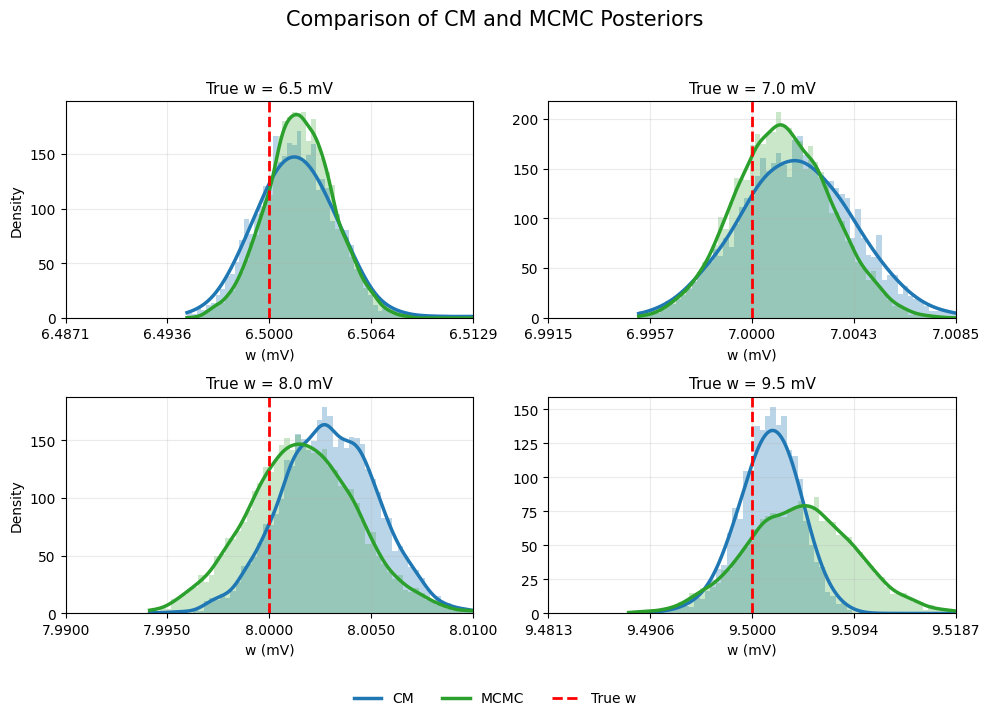


Per-weight CM time / RMSE / MCMC RMSE:
w=6.5 | CM time=1.9389s | CM RMSE=0.005711 | MCMC RMSE=0.002896
w=7.0 | CM time=1.7316s | CM RMSE=0.004308 | MCMC RMSE=0.002407
w=8.0 | CM time=1.6951s | CM RMSE=0.003769 | MCMC RMSE=0.003148
w=9.5 | CM time=1.7128s | CM RMSE=0.006730 | MCMC RMSE=0.006636

Avg CM time:  1.7696s
Avg CM RMSE:  0.005129
Avg MCMC RMSE:0.003772


In [1]:
import os, glob, json, time
from pathlib import Path
import numpy as np
import torch, arviz as az
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from model import OneDUnet

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Paths and settings
WEIGHTS     = [6.5, 7.0, 8.0, 9.5]
CM_DATA_DIR = "."
MCMC_ROOT   = "mcmc_inf_out"
ckpt_path   = "epoch_18752_trainloss_0.00000066_valloss_0.00000023.pth"
config_path = "train_config.json"
scalers_path= "scaling_params.json"

CASE      = 4     
K         = 1
Nk        = 50
NSAMPLES  = 4096
JITTER    = 0.1  

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Load scalers, configs, and model
with open(scalers_path) as f: scalers = json.load(f)
x_mean = float(np.array(scalers['x_mean']).reshape(-1)[0])
x_std  = float(np.array(scalers['x_std']).reshape(-1)[0])
y_mean = np.array(scalers['y_mean']); y_std = np.array(scalers['y_std'])

with open(config_path) as f: cfg = json.load(f)
model = OneDUnet(cfg['x_dim'], cfg['y_dim'], cfg['hidden_dim'], cfg['channels'], cfg['embedy']).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device)); model.eval()
print(f"Loaded: {os.path.basename(ckpt_path)} on {device}")

# Utility functions
def latest_case_dir(w, case):
    patt = os.path.join(MCMC_ROOT, f"w{w}_K{K}_case{case}_*")
    ds = sorted(glob.glob(patt), key=os.path.getmtime)
    return ds[-1] if ds else None

def trace_index_used_by_mcmc(w, case):
    p = Path(MCMC_ROOT) / f"indices_w{w}_K{K}_case{case}.npy"
    if p.exists(): return int(np.load(p)[0])
    d = latest_case_dir(w, case)
    if d:
        q = Path(d)/f"indices_w{w}_K{K}_case{case}.npy"
        if q.exists(): return int(np.load(q)[0])
    raise FileNotFoundError(f"no index for w={w}, case={case}")

def load_mcmc_samples(w, case):
    d = latest_case_dir(w, case)
    if not d: return None
    ncs = sorted(glob.glob(os.path.join(d, "*.nc")), key=os.path.getmtime)
    if not ncs: return None
    idata = az.from_netcdf(ncs[-1])
    if "w" not in idata.posterior: return None
    s = idata.posterior["w"].values.reshape(-1)
    s = s[np.isfinite(s)]
    return s if s.size else None

def kde(xx, s, bw=1.0):
    s = np.asarray(s, float); s = s[np.isfinite(s)]
    if s.size < 3 or np.isclose(s.std(), 0): return None
    def bwmeth(_): return gaussian_kde(s).scotts_factor() * float(bw)
    try: return gaussian_kde(s, bw_method=bwmeth)(xx)
    except Exception: return None

@torch.no_grad()
def cm_one_step(y_vec, Nk=50, nsamples=2048, jitter=0.12):
    dev = next(model.parameters()).device
    y_norm = (y_vec.reshape(1,-1) - y_mean) / (y_std + 1e-8)
    y_rep  = np.repeat(y_norm, nsamples, axis=0)
    y      = torch.tensor(y_rep, dtype=torch.float32, device=dev)

    t_hi = (Nk - 1) / Nk
    t_lo = 0.0

    x  = torch.randn((nsamples,1,1), dtype=torch.float32, device=dev)
    x  = model(x, y, torch.full((nsamples,), float(t_hi), dtype=torch.float32, device=dev))
    x  = x + (float(jitter)/Nk) * torch.randn_like(x)
    x  = model(x, y, torch.full((nsamples,), float(t_lo), dtype=torch.float32, device=dev))

    x  = x.squeeze().detach().cpu().numpy() * x_std + x_mean
    return x[np.isfinite(x)]

# Plotting
n = len(WEIGHTS)
rows, cols = (2, (n + 1) // 2)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.6 * rows), squeeze=False)
axes = axes.ravel()

rmse_cm, rmse_mcmc, cm_times = [], [], []

for i, W_TRUE in enumerate(WEIGHTS):
    ax = axes[i]

    try:
        idx = trace_index_used_by_mcmc(W_TRUE, CASE)
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha='center')
        ax.axis('off')
        rmse_cm.append(np.nan)
        rmse_mcmc.append(np.nan)
        cm_times.append(np.nan)
        continue

    yfile = Path(CM_DATA_DIR) / f"Y_w{W_TRUE}.npy"
    if not yfile.exists():
        ax.text(0.5, 0.5, f"Missing {yfile}", ha='center')
        ax.axis('off')
        rmse_cm.append(np.nan)
        rmse_mcmc.append(np.nan)
        cm_times.append(np.nan)
        continue

    Y = np.load(yfile)
    y_trace = Y[idx].reshape(-1)

    t0 = time.perf_counter()
    cm = cm_one_step(y_trace, Nk=Nk, nsamples=NSAMPLES, jitter=JITTER)
    cm_times.append(time.perf_counter() - t0)
    rmse_cm.append(np.sqrt(np.mean((cm - W_TRUE) ** 2)) if cm.size else np.nan)

    mcmc = load_mcmc_samples(W_TRUE, CASE)
    rmse_mcmc.append(np.sqrt(np.mean((mcmc - W_TRUE) ** 2)) if (mcmc is not None and mcmc.size) else np.nan)

    # Focused zoom
    all_ = np.concatenate([cm] + ([mcmc] if mcmc is not None else []))
    lo, hi = np.percentile(all_, [0.5, 99.5])
    pad = 0.08 * (hi - lo)
    lo -= pad
    hi += pad
    xx = np.linspace(lo, hi, 1200)

    ax.hist(cm, bins=60, range=(lo, hi), density=True, alpha=0.3, color="tab:blue", edgecolor='none')
    ycm = kde(xx, cm, bw=0.95)
    if ycm is not None:
        ax.plot(xx, ycm, color="tab:blue", lw=2.5, label="CM")

    if mcmc is not None and mcmc.size:
        ax.hist(mcmc, bins=60, range=(lo, hi), density=True, alpha=0.25, color="tab:green", edgecolor='none')
        ymc = kde(xx, mcmc, bw=1.00)
        if ymc is not None:
            ax.plot(xx, ymc, color="tab:green", lw=2.5, label="MCMC")

    ax.axvline(W_TRUE, ls="--", color="red", lw=2, label="True w")

    span = max(abs(W_TRUE - lo), abs(hi - W_TRUE))
    ax.set_xlim(W_TRUE - span, W_TRUE + span)
    xticks = np.linspace(W_TRUE - span, W_TRUE + span, 5)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x:.4f}" for x in xticks])

    ax.set_title(f"True w = {W_TRUE:.1f} mV", fontsize=11)
    ax.set_xlabel("w (mV)")
    if i % cols == 0:
        ax.set_ylabel("Density")
    ax.grid(alpha=0.25)

for j in range(n, rows * cols):
    axes[j].axis('off')

handles, labels = [], []
for ax in axes[:n]:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l and l not in labels:
            handles.append(h)
            labels.append(l)

fig.legend(handles, labels, loc="lower center", ncol=min(4, len(labels)), frameon=False)

plt.suptitle("Comparison of CM and MCMC Posteriors", y=0.98, fontsize=15)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("final_posterior.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary metrics
print("\nPer-weight CM time / RMSE / MCMC RMSE:")
for w, t, r1, r2 in zip(WEIGHTS, cm_times, rmse_cm, rmse_mcmc):
    print(f"w={w:.1f} | CM time={t:.4f}s | CM RMSE={r1:.6f} | MCMC RMSE={r2:.6f}")
print(f"\nAvg CM time:  {np.nanmean(cm_times):.4f}s")
print(f"Avg CM RMSE:  {np.nanmean(rmse_cm):.6f}")
print(f"Avg MCMC RMSE:{np.nanmean(rmse_mcmc):.6f}")


Loaded CM checkpoint: epoch_18752_trainloss_0.00000066_valloss_0.00000023.pth on cpu

===== Wasserstein Distance Summary =====
                        mean  median  std
Wasserstein % of range  0.04    0.04 0.03

===== MAPE Summary =====
                         MAPE-mean(%)  MAPE-std(%)
MAPE (avg across cases)          0.02       144.61

===== KDE Overlap Summary =====
                     mean  median  std
KDE Overlap Summary  0.78    0.79 0.12


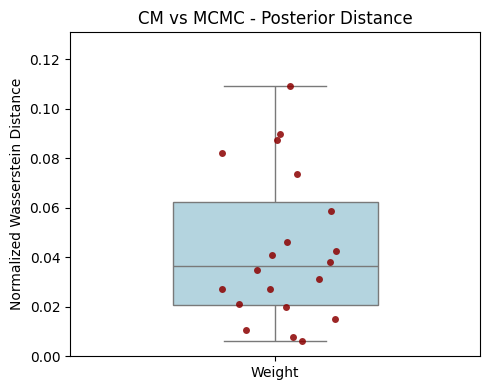

In [8]:
import os, re, json, random, glob
from pathlib import Path
import numpy as np
import torch
import pandas as pd
import arviz as az
from scipy.stats import gaussian_kde, wasserstein_distance
import matplotlib.pyplot as plt, seaborn as sns
from model import OneDUnet

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Pick whichever trapezoid integration is available (NumPy preferred, fallback to SciPy)
try:
    from numpy import trapezoid as _trapz
except Exception:
    try:
        from scipy.integrate import trapezoid as _trapz
    except Exception:
        from numpy import trapz as _trapz

# Configuration
WEIGHTS            = [6.5, 7.0, 8.0, 9.5]   # ground truth synaptic weights
CM_DATA_DIR        = "."                     # directory with simulated fluorescence traces
MCMC_ROOT          = "mcmc_inf_out"          # root folder containing MCMC results

ckpt_path          = "epoch_18752_trainloss_0.00000066_valloss_0.00000023.pth"
config_path        = "train_config.json"
scalers_path       = "scaling_params.json"

CASES_PER_WEIGHT   = 5       # number of cases per weight
NSAMPLES_CM        = 4096    # number of samples drawn from CM
PARAM_RANGE        = 4.0     # normalization constant for Wasserstein distance
EPS                = 1e-8

# Consistency Model (CM) inference parameters
NK_TRAIN           = 50
T_HI               = (NK_TRAIN - 1) / NK_TRAIN
T_LO               = 0.0
JITTER             = 0.1  

# Random seeds for reproducibility
RANDOM_SEED        = 120
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Device setup
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Load model and scalars
with open(scalers_path) as f:
    scalers = json.load(f)
x_mean = float(np.array(scalers["x_mean"]).reshape(-1)[0])
x_std  = float(np.array(scalers["x_std"]).reshape(-1)[0])
y_mean = np.array(scalers["y_mean"])
y_std  = np.array(scalers["y_std"])

with open(config_path) as f:
    cfg = json.load(f)

assert cfg["y_dim"] == 600, f"Expected y_dim=600, got {cfg['y_dim']}"

# Load model
model = OneDUnet(cfg["x_dim"], cfg["y_dim"], cfg["hidden_dim"],
                 cfg["channels"], cfg["embedy"]).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()
print(f"Loaded CM checkpoint: {os.path.basename(ckpt_path)} on {device}")

# Utility functions
def trace_index_used_by_mcmc(weight, case, k=1):
    """Retrieve which trace index was used by MCMC for this (weight, case)."""
    path = Path(MCMC_ROOT) / f"indices_w{weight}_K{k}_case{case}.npy"
    if path.exists():
        return int(np.load(path)[0])
    patt = os.path.join(MCMC_ROOT, f"w{weight}_K{k}_case{case}_*")
    ds = sorted(glob.glob(patt), key=os.path.getmtime)
    if ds:
        q = Path(ds[-1]) / f"indices_w{weight}_K{k}_case{case}.npy"
        if q.exists():
            return int(np.load(q)[0])
    raise FileNotFoundError(f"Index not found for w={weight}, case={case}")

def find_nc_for_weight_case(weight, case, k=1):
    """Find the latest NetCDF file that stores MCMC posterior samples."""
    patt = re.compile(rf"w{weight:.1f}_K{k}_case{case}")
    candidates = []
    for root, _, files in os.walk(MCMC_ROOT):
        for fn in files:
            if fn.endswith(".nc") and patt.search(fn):
                candidates.append(os.path.join(root, fn))
    if not candidates:
        return None
    candidates.sort(key=os.path.getmtime)
    return candidates[-1]

def load_mcmc_case_samples(weight, case, k=1):
    """Load posterior samples of synaptic weight from MCMC output."""
    nc = find_nc_for_weight_case(weight, case, k=k)
    if nc is None:
        return np.array([])
    try:
        idata = az.from_netcdf(nc)
        s = idata.posterior["w"].values.reshape(-1)
        return s[np.isfinite(s)]
    except Exception as e:
        print(f"Failed to read {nc}: {e}")
        return np.array([])

def cm_posterior_single_trace(y_trace, nsamples=4096,
                              t_hi=T_HI, t_lo=T_LO,
                              Nk_train=NK_TRAIN, jitter=JITTER):
    """Run one-step consistency model inference for a single observed trace."""
    # Normalize input trace
    yf = y_trace.reshape(1, -1)
    y_norm = (yf - y_mean) / (y_std + 1e-8)
    y_rep = np.repeat(y_norm, nsamples, axis=0)
    y_t = torch.tensor(y_rep, dtype=torch.float32, device=device)

    # Start from random latent seeds
    x = torch.randn((nsamples, 1, 1), dtype=torch.float32, device=device)

    with torch.inference_mode():
        # First denoising step at t_hi
        t_hi_vec = torch.full((nsamples,), float(t_hi), dtype=torch.float32, device=device)
        x = model(x, y_t, t_hi_vec)

        # Add jitter for robustness
        if jitter and jitter > 0.0:
            x = x + (float(jitter) / Nk_train) * torch.randn_like(x)

        # Final clean pass at t=0
        t0_vec = torch.zeros((nsamples,), dtype=torch.float32, device=device)
        x = model(x, y_t, t0_vec)

    # Convert back to physical units
    w_samps = x.squeeze().detach().cpu().numpy() * x_std + x_mean
    return w_samps[np.isfinite(w_samps)]

def kde_overlap(a, b, grid=None):
    """Compute overlap between two distributions via KDE."""
    a = np.asarray(a); b = np.asarray(b)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if a.size < 3 or b.size < 3:
        return np.nan
    if np.std(a) < 1e-8: a = a + np.random.normal(0, 1e-6, size=a.size)
    if np.std(b) < 1e-8: b = b + np.random.normal(0, 1e-6, size=b.size)

    pooled = np.concatenate([a, b])
    lo = np.percentile(pooled, 0.5); hi = np.percentile(pooled, 99.5)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        mu = float(np.mean(pooled)); sd = float(np.std(pooled)) + 1e-6
        lo, hi = mu - 3*sd, mu + 3*sd
    if grid is None:
        grid = np.linspace(lo, hi, 1000)

    try:
        pa = gaussian_kde(a)(grid)
        pb = gaussian_kde(b)(grid)
    except Exception:
        return np.nan

    Za, Zb = _trapz(pa, grid), _trapz(pb, grid)
    if Za <= 0 or Zb <= 0:
        return np.nan
    pa /= Za; pb /= Zb
    return float(_trapz(np.minimum(pa, pb), grid))

# MAIN: RUN COMPARISON 
rows = []
for w in WEIGHTS:
    yfile = Path(CM_DATA_DIR) / f"Y_w{w}.npy"   # simulated fluorescence traces (N, 2, T)
    if not yfile.exists():
        # If traces are missing, record NaNs for all cases
        for case in range(CASES_PER_WEIGHT):
            rows.append({"weight": w, "case": case,
                         "mu_CM": np.nan, "mu_MCMC": np.nan,
                         "sd_CM": np.nan, "sd_MCMC": np.nan,
                         "MAPE-mean(%)": np.nan, "MAPE-std(%)": np.nan,
                         "WassNorm(%)": np.nan, "KDE Overlap": np.nan})
        continue

    Y = np.load(yfile)  # shape (N, 2, T)
    N = Y.shape[0]

    for case in range(CASES_PER_WEIGHT):
        try:
            idx = trace_index_used_by_mcmc(w, case, k=1)
        except Exception:
            rows.append({"weight": w, "case": case,
                         "mu_CM": np.nan, "mu_MCMC": np.nan,
                         "sd_CM": np.nan, "sd_MCMC": np.nan,
                         "MAPE-mean(%)": np.nan, "MAPE-std(%)": np.nan,
                         "WassNorm(%)": np.nan, "KDE Overlap": np.nan})
            continue

        # Take the correct fluorescence trace and flatten both neurons (2×300 → 600)
        idx_mod = int(idx % N)
        y_trace = Y[idx_mod].reshape(-1)

        # Run CM inference
        cm_samples = cm_posterior_single_trace(
            y_trace,
            nsamples=NSAMPLES_CM,
            t_hi=T_HI, t_lo=T_LO,
            Nk_train=NK_TRAIN,
            jitter=JITTER
        )

        # Load MCMC posterior for the same trace
        mcmc_samples = load_mcmc_case_samples(w, case, k=1)

        cm_case, mcmc_case = np.asarray(cm_samples), np.asarray(mcmc_samples)
        if cm_case.size < 3 or mcmc_case.size < 3:
            rows.append({"weight": w, "case": case,
                         "mu_CM": np.nan, "mu_MCMC": np.nan,
                         "sd_CM": np.nan, "sd_MCMC": np.nan,
                         "MAPE-mean(%)": np.nan, "MAPE-std(%)": np.nan,
                         "WassNorm(%)": np.nan, "KDE Overlap": np.nan})
            continue

        # Compute summary statistics and error metrics
        mu_a, mu_b = float(np.mean(cm_case)), float(np.mean(mcmc_case))
        sd_a, sd_b = float(np.std(cm_case, ddof=0)), float(np.std(mcmc_case, ddof=0))

        mape_mean = abs(mu_a - mu_b) / (abs(mu_b) + EPS)
        mape_std  = abs(sd_a - sd_b) / max(sd_b, EPS)
        wdist_pct = 100.0 * wasserstein_distance(cm_case, mcmc_case) / max(PARAM_RANGE, EPS)
        ovl       = kde_overlap(cm_case, mcmc_case)

        rows.append({
            "weight": w, "case": case,
            "mu_CM": mu_a, "mu_MCMC": mu_b,
            "sd_CM": sd_a, "sd_MCMC": sd_b,
            "MAPE-mean(%)": 100*mape_mean,
            "MAPE-std(%)":  100*mape_std,
            "WassNorm(%)":  wdist_pct,
            "KDE Overlap":  ovl
        })

per_case = pd.DataFrame(rows)

# Summary Tables
pd.options.display.float_format = lambda x: f"{x:0.2f}"

summary_wass = per_case["WassNorm(%)"].agg(["mean","median","std"]).to_frame().T
summary_wass.index = ["Wasserstein % of range"]
print("\n===== Wasserstein Distance Summary =====")
print(summary_wass.to_string())

summary_mape = per_case[["MAPE-mean(%)","MAPE-std(%)"]].mean().to_frame().T
summary_mape.index = ["MAPE (avg across cases)"]
print("\n===== MAPE Summary =====")
print(summary_mape.to_string())

summary_kde = per_case["KDE Overlap"].agg(["mean","median","std"]).to_frame().T
summary_kde.index = ["KDE Overlap Summary"]
print("\n===== KDE Overlap Summary =====")
print(summary_kde.to_string())

# Plot results
df_plot = per_case[["WassNorm(%)"]].rename(columns={"WassNorm(%)": "WassNorm"}).copy()
if df_plot["WassNorm"].max() > 1.0:
    df_plot["WassNorm"] = df_plot["WassNorm"] / 100.0
df_plot["Parameter"] = "Weight"

plt.figure(figsize=(5,4))
sns.boxplot(data=df_plot, x="Parameter", y="WassNorm",
            color="lightblue", width=0.5, showfliers=False)
sns.stripplot(data=df_plot, x="Parameter", y="WassNorm",
              alpha=0.85, jitter=0.15, size=5, color="darkred")

plt.ylabel("Normalized Wasserstein Distance")
plt.xlabel("")
plt.title(f"CM vs MCMC - Posterior Distance")
ymax = float(df_plot["WassNorm"].max()) * 1.2
plt.ylim(0, ymax if ymax > 0 else 0.05)
plt.tight_layout()
plt.savefig(f"Box-plot", dpi=300, bbox_inches="tight")
plt.show()
